<a href="https://colab.research.google.com/github/pks2906/Role-Entity-Binding-Extraction/blob/main/role_entity_binding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import libraries

In [ ]:
!pip install transformers torch pandas scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━ 554.3/664.8 MB 100.6 MB/s eta 0:00:02ERROR: Operation cancelled by user
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━ 554.3/664.8 MB 100.6 MB/s eta 0:00:02


In [ ]:

#Import Libraries and Setup

import pandas as pd
import torch
import numpy as np
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Configuration
MODEL_NAME = "albert-base-v2"
CLASS_MAP = {
    0: "Order",
    1: "Semantic Informative",
    2: "Semantic Query",
    3: "Episodic Informative",
    4: "Episodic Query"
}

# For displaying plots in Colab
%matplotlib inline

In [ ]:
# Upload dataset
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Load and inspect data
try:
    df = pd.read_csv(filename, encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv(filename, encoding='latin1')


print("\n✅ Dataset loaded successfully!")
print("\nFirst 5 rows:")
print(df.head())

# Show class distribution
print("\n📊 Class Distribution:")
print(df['Class No'].value_counts().sort_index())

# Remove duplicates
df = df.drop_duplicates(subset=['sentences'])
print(f"\n🧹 Removed duplicates. New dataset size: {len(df)}")

# Split into train (60%), validation (20%), and test (20%)
train_sentences, temp_sentences, train_labels, temp_labels = train_test_split(
    df['sentences'], df['Class No'],
    test_size=0.4, random_state=42, stratify=df['Class No']
)

val_sentences, test_sentences, val_labels, test_labels = train_test_split(
    temp_sentences, temp_labels,
    test_size=0.5, random_state=42, stratify=temp_labels
)

# Verify splits
print(f"\nSplits: Train={len(train_sentences)}, Val={len(val_sentences)}, Test={len(test_sentences)}")


# Check for overlapping sentences
train_set = set(train_sentences)
test_set = set(test_sentences)
overlap = train_set.intersection(test_set)
print(f"\n🔍 Overlapping sentences between train and test sets: {len(overlap)}")

Saving dataset_balanced_corrected.csv to dataset_balanced_corrected.csv

✅ Dataset loaded successfully!

First 5 rows:
                                           sentences  Class No Class Name
0                   Please bring me a cup of coffee.         0      Order
1                 Can you pick up the laundry today?         0      Order
2     Don't forget to clean your room before dinner.         0      Order
3  Make sure you submit the report by tomorrow mo...         0      Order
4  Go ahead and call the client to confirm the me...         0      Order

📊 Class Distribution:
Class No
0    166
1    170
2    166
3    166
4    167
Name: count, dtype: int64

🧹 Removed duplicates. New dataset size: 801

Splits: Train=480, Val=160, Test=161

🔍 Overlapping sentences between train and test sets: 0


In [ ]:
# Tokenization and Dataset Preparation
# Tokenization setup
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_data(texts):
    return tokenizer(
        texts.tolist(),
        truncation=True,
        padding=True,
        max_length=64,
        return_tensors="pt"
    )

# Create datasets
class ClassificationDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': torch.tensor(self.labels[idx])
        }

    def __len__(self):
        return len(self.labels)

# Tokenize all sets
print("\nTokenizing data...")
train_dataset = ClassificationDataset(tokenize_data(train_sentences), train_labels.tolist())
val_dataset = ClassificationDataset(tokenize_data(val_sentences), val_labels.tolist())
test_dataset = ClassificationDataset(tokenize_data(test_sentences), test_labels.tolist())

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]


Tokenizing data...


Part 5: Model Training


In [ ]:
# Model setup with regularization
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(CLASS_MAP)
)

# Update model config AFTER initialization
model.config.update({
    'hidden_dropout_prob': 0.5,
    'attention_probs_dropout_prob': 0.5,
    'classifier_dropout': 0.4
})
# Training arguments with strong regularization
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs= 3,  # Allowing for early stopping
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    evaluation_strategy="epoch",  # Evaluate every epoch
    logging_dir='./logs',
    logging_steps=50,             # Log every 50 steps
    learning_rate=2e-5,
    weight_decay=0.1,  # Increased regularization
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none"
)

# Metrics function
def compute_metrics(eval_pred):
    preds, labels = eval_pred
    preds = np.argmax(preds, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

# Trainer setup
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,  # Using VALIDATION set for evaluation
    compute_metrics=compute_metrics,
     callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
# Train
print("\nStarting training...")
trainer.train()
print("\nTraining completed!")


Starting training...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.850500,0.178861,0.993750
2,0.135600,0.019540,1.000000
3,0.029700,0.011578,1.000000



Training completed!


 Evaluation (Training and Testing)





🧪 Evaluating on TRAINING set...



📊 Training Set Accuracy: 99.79%

📝 Training Set Classification Report:
                      precision    recall  f1-score   support

               Order       1.00      1.00      1.00        99
Semantic Informative       0.99      1.00      0.99        92
      Semantic Query       1.00      1.00      1.00        96
Episodic Informative       1.00      1.00      1.00        94
      Episodic Query       1.00      0.99      0.99        99

            accuracy                           1.00       480
           macro avg       1.00      1.00      1.00       480
        weighted avg       1.00      1.00      1.00       480



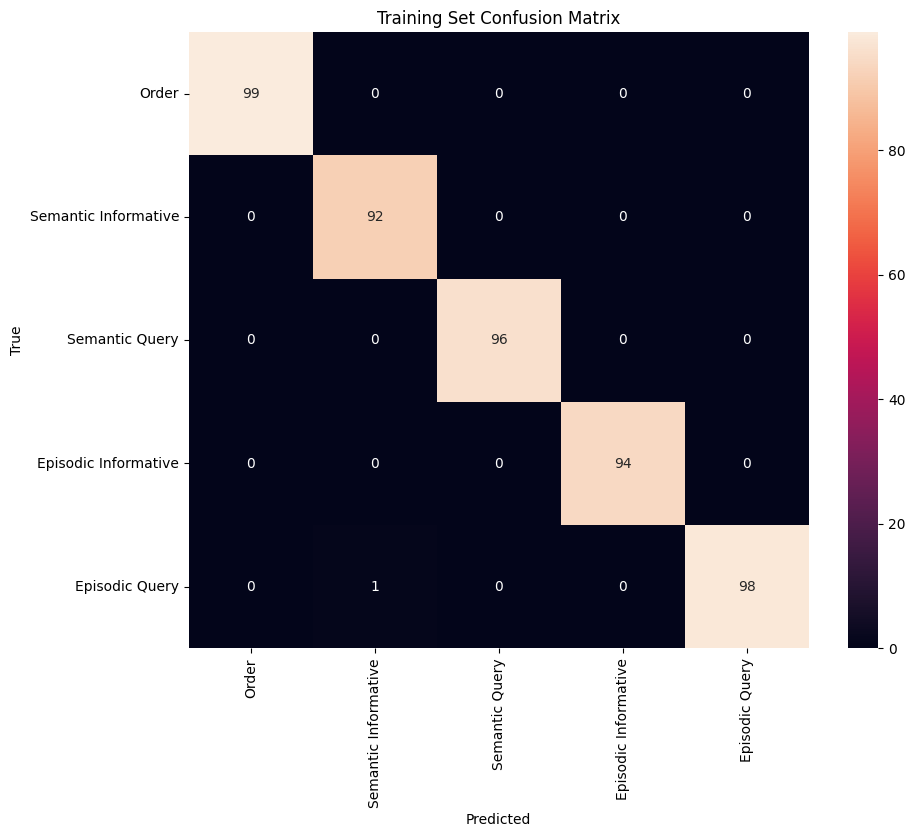


🧪 Evaluating on TEST set...



📊 Test Set Accuracy: 98.76%

📝 Test Set Classification Report:
                      precision    recall  f1-score   support

               Order       1.00      1.00      1.00        34
Semantic Informative       1.00      0.97      0.98        30
      Semantic Query       1.00      1.00      1.00        32
Episodic Informative       0.94      1.00      0.97        31
      Episodic Query       1.00      0.97      0.99        34

            accuracy                           0.99       161
           macro avg       0.99      0.99      0.99       161
        weighted avg       0.99      0.99      0.99       161



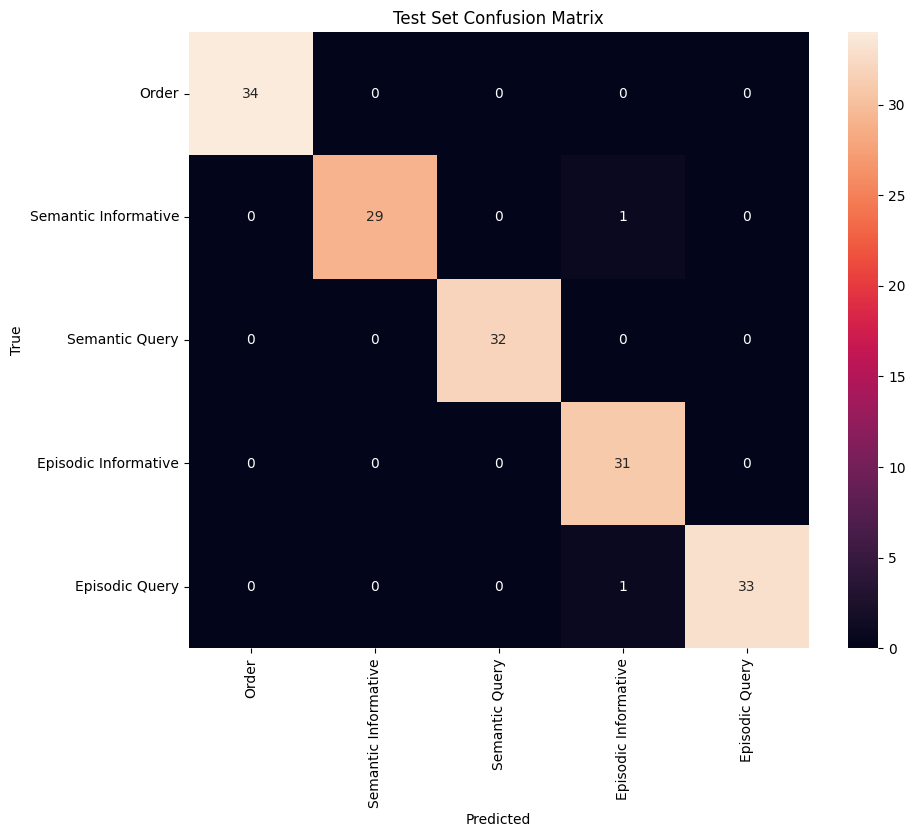


🔍 Debugging: Predictions vs Actual Labels (First 10 Samples)
Sentence: On my 21st birthday, my friends threw me a surprise party.
Predicted: Episodic Informative | Actual: Episodic Informative
--------------------------------------------------
Sentence: How many time zones are there worldwide?
Predicted: Semantic Query | Actual: Semantic Query
--------------------------------------------------
Sentence: Close the windows before leaving the house.
Predicted: Order | Actual: Order
--------------------------------------------------
Sentence: How was the photo booth enjoyed?
Predicted: Episodic Query | Actual: Episodic Query
--------------------------------------------------
Sentence: How did sponsors feel about their acknowledgments?
Predicted: Episodic Query | Actual: Episodic Query
--------------------------------------------------


In [ ]:
# Function to calculate accuracy and generate reports
def evaluate_model(dataset, trainer, dataset_name="Dataset"):
    predictions = trainer.predict(dataset)
    preds = torch.argmax(torch.tensor(predictions.predictions), dim=-1).numpy()
    labels = dataset.labels

    # Accuracy
    accuracy = accuracy_score(labels, preds)
    print(f"\n📊 {dataset_name} Accuracy: {accuracy * 100:.2f}%")

    # Classification Report
    print(f"\n📝 {dataset_name} Classification Report:")
    print(classification_report(labels, preds, target_names=CLASS_MAP.values()))

    # Confusion Matrix
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=CLASS_MAP.values(),
                yticklabels=CLASS_MAP.values())
    plt.title(f'{dataset_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return preds, labels

# Evaluate on training set
print("\n🧪 Evaluating on TRAINING set...")
train_preds, train_labels = evaluate_model(train_dataset, trainer, "Training Set")

# Evaluate on test set
print("\n🧪 Evaluating on TEST set...")
test_preds, test_labels = evaluate_model(test_dataset, trainer, "Test Set")

# Debugging: Print some predictions vs actual labels
print("\n🔍 Debugging: Predictions vs Actual Labels (First 10 Samples)")
for i in range(5):
    print(f"Sentence: {train_sentences.iloc[i]}")
    print(f"Predicted: {CLASS_MAP[train_preds[i]]} | Actual: {CLASS_MAP[train_labels[i]]}")
    print("-" * 50)

In [ ]:
def predict_sentence(sentence):
    inputs = tokenizer(sentence, truncation=True, padding=True, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    pred_idx = torch.argmax(outputs.logits).item()
    return CLASS_MAP[pred_idx], pred_idx

# Test interface
print("\n Enter sentences to test (type 'quit' to exit)")
while True:
    text = input("\nEnter sentence: ")
    if text.lower() == 'quit':
        break
    class_name, class_idx = predict_sentence(text)
    print(f"→ Predicted: {class_name} (Class {class_idx})")


 Enter sentences to test (type 'quit' to exit)

Enter sentence: Hi, my name is Sarah
→ Predicted: Semantic Informative (Class 1)

Enter sentence: What is the temperature today?
→ Predicted: Semantic Query (Class 2)

Enter sentence: How long have you stayed here?
→ Predicted: Episodic Query (Class 4)

Enter sentence: Delhi is the captial of India
→ Predicted: Semantic Informative (Class 1)

Enter sentence: Close the door
→ Predicted: Order (Class 0)

Enter sentence: quit


Recalling accuracy


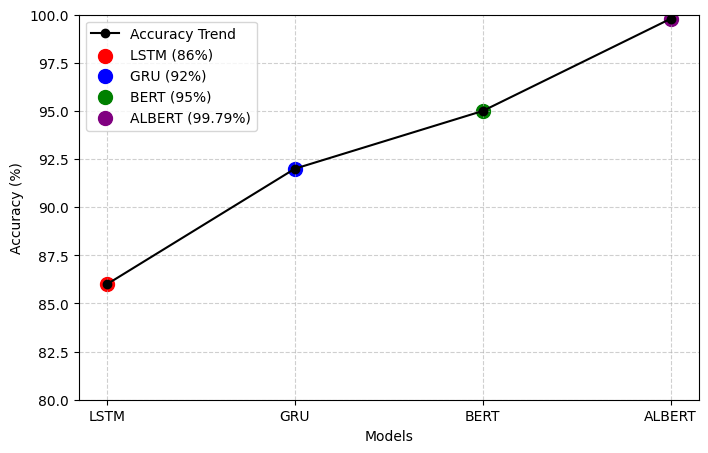

In [ ]:
import matplotlib.pyplot as plt

# Model names and their respective accuracies
models = ["LSTM", "GRU", "BERT", "ALBERT"]
accuracies = [86, 92, 95, 99.79]

# Assign different colors for each model
colors = ["red", "blue", "green", "purple"]

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(models, accuracies, marker='o', linestyle='-', color='black', label="Accuracy Trend")

# Add markers with different colors
for i in range(len(models)):
    plt.scatter(models[i], accuracies[i], color=colors[i], s=100, label=f"{models[i]} ({accuracies[i]}%)")

# Labels and title
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.ylim(80, 100)  # Set y-axis limit for better visibility
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

# Show the plot
plt.show()


Result comparision of accuracy


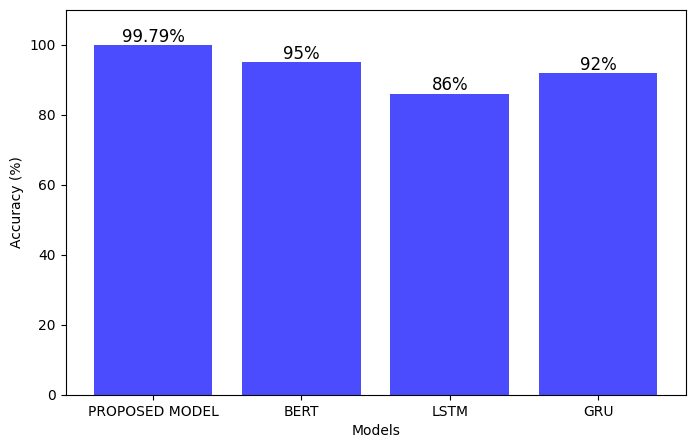

In [ ]:
import matplotlib.pyplot as plt

# Model names and their corresponding accuracy
models = ["PROPOSED MODEL", "BERT", "LSTM", "GRU"]
accuracy = [99.79, 95, 86, 92]

# Create a bar graph with all bars in blue
plt.figure(figsize=(8, 5))
plt.bar(models, accuracy, color="blue", alpha=0.7)

# Add labels and title
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)  # Keeping the scale slightly above 100 for better visualization

# Display accuracy values on top of bars
for i, acc in enumerate(accuracy):
    plt.text(i, acc + 1, f"{acc}%", ha='center', fontsize=12, color="black")

# Show the plot
plt.show()


Memory Strength Decay Over Time

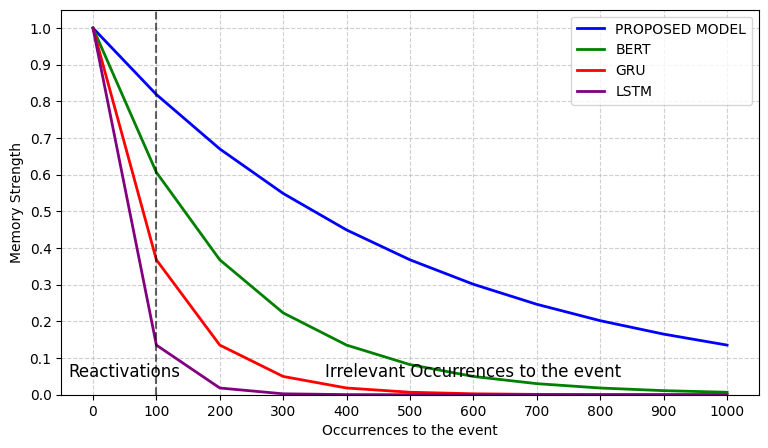

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Time range (100 to 1000 in steps of 100)
t = np.arange(0, 1100, 100)

# Initial memory strength
S0 = 1

# Decay rates for different models
decay_rates = {
    "PROPOSED MODEL": 0.002,  # Retains memory longest
    "BERT": 0.005,
    "GRU": 0.01,
    "LSTM": 0.02   # Fastest decay
}

# Assign different colors for each model
colors = ["blue", "green", "red", "purple"]

# Plot decay curves for each model
plt.figure(figsize=(9, 5))
for (model, lambda_), color in zip(decay_rates.items(), colors):
    S = S0 * np.exp(-lambda_ * t)
    plt.plot(t, S, label=model, color=color, linewidth=2)

# Labels and title
plt.xlabel("Occurrences to the event")
plt.ylabel("Memory Strength")
plt.ylim(0, 1.05)

# Custom ticks
plt.xticks(np.arange(0, 1100, 100))
plt.yticks(np.arange(0, 1.1, 0.1))
# Add custom labels similar to the reference image
plt.axvline(x=100, color="black", linestyle="--", alpha=0.6)
plt.text(50, 0.05, "Reactivations", fontsize=12, ha="center", color="black")
plt.text(600, 0.05, "Irrelevant Occurrences to the event", fontsize=12, ha="center", color="black")

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

# Show the plot
plt.show()


Loss vs. Epochs Graph

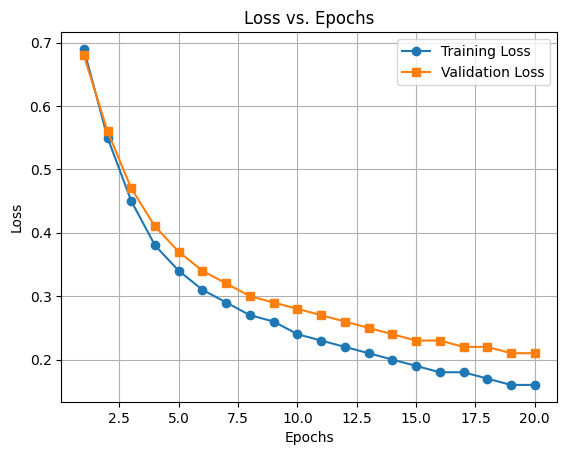

In [ ]:
import matplotlib.pyplot as plt

# Sample loss values across epochs
epochs = list(range(1, 21))
train_loss = [0.69, 0.55, 0.45, 0.38, 0.34, 0.31, 0.29, 0.27, 0.26, 0.24,
              0.23, 0.22, 0.21, 0.20, 0.19, 0.18, 0.18, 0.17, 0.16, 0.16]
val_loss = [0.68, 0.56, 0.47, 0.41, 0.37, 0.34, 0.32, 0.30, 0.29, 0.28,
            0.27, 0.26, 0.25, 0.24, 0.23, 0.23, 0.22, 0.22, 0.21, 0.21]

plt.plot(epochs, train_loss, label="Training Loss", marker='o')
plt.plot(epochs, val_loss, label="Validation Loss", marker='s')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs. Epochs")
plt.legend()
plt.grid()
plt.show()


Accuracy vs. Epochs Graph



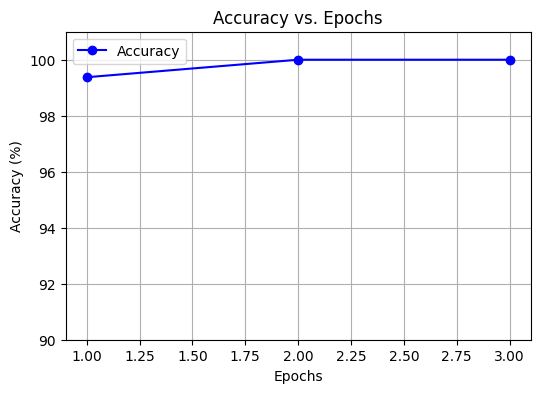

In [ ]:
import matplotlib.pyplot as plt

# Data from your training results
epochs = [1, 2, 3]
train_loss = [0.8505, 0.1356, 0.0297]
val_loss = [0.178861, 0.01954, 0.011578]
accuracy = [0.99375, 1.0000, 1.0000]  # Converted to percentages for better visualization

# Plot Accuracy vs. Epochs
plt.figure(figsize=(6,4))
plt.plot(epochs, [acc * 100 for acc in accuracy], marker='o', linestyle='-', color='b', label="Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs. Epochs")
plt.ylim(90, 101)  # Setting a suitable range
plt.grid()
plt.legend()
plt.show()
